In [25]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
sys.path.insert(1, r'C:\Users\Dharmendra Vartika\LLM\env')
from enviorment import load_env
import os 
load_env()
model =ChatOpenAI()
from langgraph.graph import StateGraph,START, END
from typing import TypedDict,Annotated
import operator


In [26]:
class bot(TypedDict):
    messages :Annotated[list[BaseMessage], add_messages]

In [21]:
thread_id=1
def Chatbot(state:bot):
    
    while True:
        text ='what is AI'
        messages =[HumanMessage(text)]
        if text=='exit':
            break
        else:
            config = {"configurable": {"thread_id": "1"}}
            result=model.invoke (text,config=config)
            messages =[AIMessage(result.content)]
    return {'messages' :[messages]}



In [39]:

def Chatbot_mod(state:bot):
    text=state['messages']
    
    result=model.invoke (text,config=config)
    messages =[AIMessage(result)]
    print ('messages ',messages)
    return {'messages' :[messages]}



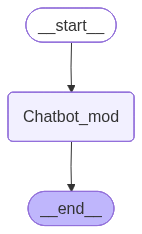

In [36]:
checkpoint =InMemorySaver()

graph=StateGraph(bot)
graph.add_node('Chatbot_mod',Chatbot_mod)
graph.add_edge(START,'Chatbot_mod')
graph.add_edge('Chatbot_mod',END)
workflow =graph.compile(checkpointer=checkpoint)
workflow



In [41]:
text ='What ia AI'
config = {"configurable": {"thread_id": "1"}}
initial_state={'messages' :[HumanMessage(content=text)]}
message ={'messages':[HumanMessage(content=text)]}
workflow.invoke(initial_state,config=config)

messages  [AIMessage(content='AI stands for artificial intelligence, which is the simulation of human intelligence processes by machines. This includes learning, reasoning, problem-solving, perception, and language understanding. AI technologies allow machines to perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation. AI is a rapidly evolving field that has the potential to revolutionize various industries and aspects of our daily lives.', additional_kwargs={}, response_metadata={})]


NotImplementedError: Unsupported message type: <class 'list'>
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/MESSAGE_COERCION_FAILURE 

In [18]:
thread_id=1
while True:
        text =input ('User :')
        messages =[HumanMessage(text)]
        if text=='exit':
            break
        else:
            config = {"configurable": {"thread_id": "1"}}
            result=model.invoke (text,config=config)
            messages =[AIMessage(result.content)]
            print('messages' ,messages)
print('messages final' ,messages)


messages [AIMessage(content='I am a virtual assistant trained to help with a variety of tasks such as answering questions, providing information, and assisting with various requests. Just let me know how I can help you!', additional_kwargs={}, response_metadata={})]
messages [AIMessage(content='2+2 equals 4.', additional_kwargs={}, response_metadata={})]
messages [AIMessage(content='Sure, if you provide me with the result, I can multiply it by 4 for you. Just let me know what the number is.', additional_kwargs={}, response_metadata={})]
messages final [HumanMessage(content='exit', additional_kwargs={}, response_metadata={})]
